In [33]:
!nvidia-smi

Sun Mar 22 05:51:42 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   59C    P8             16W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
col_names = [
    'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM',
    'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV'
]

url = 'https://raw.githubusercontent.com/Pranav19joshi/House-Prediction/main/housing.csv'
df = pd.read_csv(url, header=0, names=col_names, sep=r'\s+', engine='python')

print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (505, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
1,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
2,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
3,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
4,0.02985,0.0,2.18,0,0.458,6.430,58.7,6.0622,3,222.0,18.7,394.12,5.21,28.7


## 2. Data Cleaning

In [36]:
# --- Missing values ---
print('Missing values:', df.isnull().sum().sum())
for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

# --- Duplicates ---
n_dup = df.duplicated().sum()
if n_dup:
    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)
print(f'Duplicates removed: {n_dup}')

# --- Outlier capping (IQR, skip binary CHAS and target MEDV) ---
for col in df.columns:
    if col in ['CHAS', 'MEDV']:
        continue
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    df[col] = df[col].clip(Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)

# --- Log-transform highly skewed features ---
skewed = df.skew()
for col in skewed[abs(skewed) > 1].index:
    if col not in ['CHAS', 'MEDV']:
        df[col] = np.log1p(df[col])

df['CHAS'] = df['CHAS'].astype(int)
df['RAD']  = df['RAD'].astype(int)

print(f'Clean dataset shape: {df.shape}')
df.head()

Missing values: 0
Duplicates removed: 0
Clean dataset shape: (505, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.026944,0.0,7.07,0,0.469,6.421,78.9,4.9671,1,242.0,17.8,5.986201,9.14,21.6
1,0.026924,0.0,7.07,0,0.469,7.185,61.1,4.9671,1,242.0,17.8,5.975919,4.03,34.7
2,0.031857,0.0,2.18,0,0.458,6.998,45.8,6.0622,1,222.0,18.7,5.980479,2.94,33.4
3,0.066770,0.0,2.18,0,0.458,7.147,54.2,6.0622,1,222.0,18.7,5.986201,5.33,36.2
4,0.029413,0.0,2.18,0,0.458,6.430,58.7,6.0622,1,222.0,18.7,5.979190,5.21,28.7


---
## 3. Linear Regression Model

In [37]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('Libraries loaded.')

Libraries loaded.


### 3.1 Train / Test Split

In [38]:
X = df.drop('MEDV', axis=1)
y = df['MEDV']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f'Training samples : {X_train.shape[0]}')
print(f'Test samples     : {X_test.shape[0]}')
print(f'Features         : {X_train.shape[1]}')

Training samples : 404
Test samples     : 101
Features         : 13


### 3.2 Train the Model

In [40]:
# Pipeline: scale features then fit Linear Regression
model = Pipeline([
    ('scaler', StandardScaler()),
    ('lr',     LinearRegression())
])

model.fit(X_train, y_train)
print('Model trained successfully.')

Model trained successfully.


### 3.3 Cross-Validation (5-Fold)

In [41]:
cv_scores = cross_val_score(
    model, X_train, y_train,
    cv=5, scoring='neg_root_mean_squared_error'
)
cv_rmse = -cv_scores

print('=== 5-Fold Cross-Validation RMSE ===')
for i, score in enumerate(cv_rmse, 1):
    print(f'  Fold {i}: {score:.4f}')
print(f'  Mean : {cv_rmse.mean():.4f}')
print(f'  Std  : {cv_rmse.std():.4f}')

=== 5-Fold Cross-Validation RMSE ===
  Fold 1: 4.3083
  Fold 2: 5.7083
  Fold 3: 6.2219
  Fold 4: 4.7769
  Fold 5: 4.7776
  Mean : 5.1586
  Std  : 0.6995


### 3.4 Evaluate on Test Set

In [42]:
y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print('=== Test Set Metrics ===')
print(f'  MAE  : {mae:.4f}  ($1,000s)')
print(f'  RMSE : {rmse:.4f}  ($1,000s)')
print(f'  R²   : {r2:.4f}')

=== Test Set Metrics ===
  MAE  : 3.2281  ($1,000s)
  RMSE : 4.2633  ($1,000s)
  R²   : 0.6738


### 3.5 Visualisations

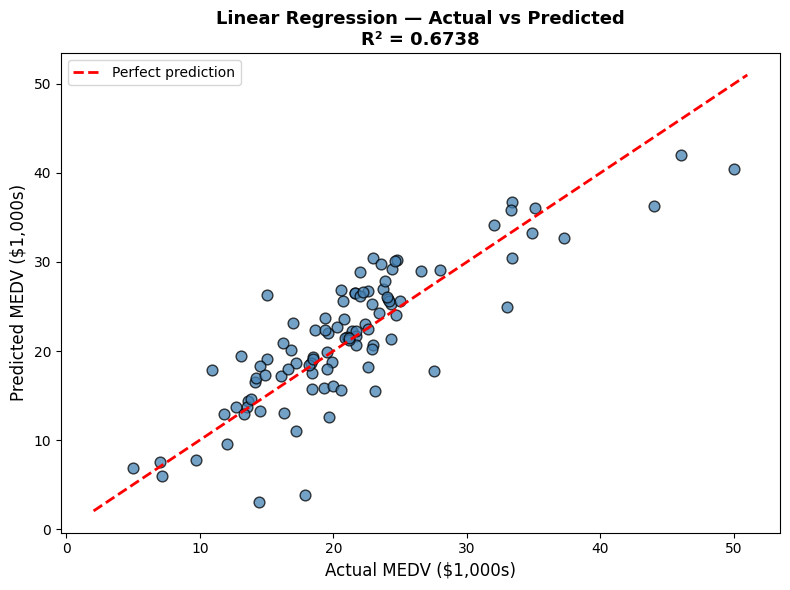

In [43]:
# --- Actual vs Predicted ---
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.75, color='steelblue', edgecolors='k', s=60)
lim = [min(y_test.min(), y_pred.min()) - 1,
       max(y_test.max(), y_pred.max()) + 1]
plt.plot(lim, lim, 'r--', lw=2, label='Perfect prediction')
plt.xlabel('Actual MEDV ($1,000s)', fontsize=12)
plt.ylabel('Predicted MEDV ($1,000s)', fontsize=12)
plt.title(f'Linear Regression — Actual vs Predicted\nR² = {r2:.4f}',
          fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()